In [1]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [2]:
X_train.shape

(55000, 28, 28)

In [3]:
y_train.shape

(55000,)

In [4]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [5]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [6]:
class_names[y_train[0]]

'Ankle boot'

In [7]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=[28, 28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [10]:
model.layers[1].name


'dense'

In [11]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [12]:
model.get_layer('dense') is hidden1

True

In [13]:
weights, biases = hidden1.get_weights()
weights

array([[-0.04427228,  0.00021862,  0.0046004 , ..., -0.0329583 ,
        -0.02708938, -0.05350909],
       [ 0.05866647, -0.03481504, -0.07268031, ...,  0.04871352,
         0.02404084, -0.05003407],
       [ 0.02734277,  0.00189067,  0.01429746, ...,  0.00111961,
         0.05505218, -0.04380404],
       ...,
       [ 0.03312161,  0.03486689,  0.03445438, ...,  0.02059598,
         0.05059545, -0.02214555],
       [ 0.07105008, -0.06194067,  0.04273257, ..., -0.06461535,
        -0.06722979, -0.06519342],
       [-0.02925595, -0.02277352, -0.03650486, ..., -0.05746792,
         0.07249609, -0.05109321]], shape=(784, 300), dtype=float32)

In [14]:
weights.shape

(784, 300)

In [15]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [16]:
biases.shape

(300,)

In [17]:
model.compile(loss="sparse_categorical_crossentropy",
optimizer="sgd",
metrics=["accuracy"])

In [18]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7651 - loss: 0.7187 - val_accuracy: 0.8296 - val_loss: 0.5076
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8327 - loss: 0.4843 - val_accuracy: 0.8402 - val_loss: 0.4530
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8466 - loss: 0.4381 - val_accuracy: 0.8480 - val_loss: 0.4286
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8549 - loss: 0.4112 - val_accuracy: 0.8532 - val_loss: 0.4123
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8615 - loss: 0.3915 - val_accuracy: 0.8562 - val_loss: 0.3998
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8670 - loss: 0.3760 - val_accuracy: 0.8590 - val_loss: 0.3888
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8713 - loss: 0.3628 - val_accuracy: 0.8610 - val_loss: 0.3795
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8750 - loss: 0.351

In [19]:
history.history

{'accuracy': [0.7651273012161255,
  0.8327090740203857,
  0.8465999960899353,
  0.8549454808235168,
  0.8615090847015381,
  0.8669999837875366,
  0.871290922164917,
  0.875,
  0.8789272904396057,
  0.8813454508781433,
  0.8846181631088257,
  0.887218177318573,
  0.8895454406738281,
  0.8916363716125488,
  0.8938727378845215,
  0.8959454298019409,
  0.8978363871574402,
  0.8999272584915161,
  0.9021818041801453,
  0.9039999842643738,
  0.905927300453186,
  0.9074181914329529,
  0.9085090756416321,
  0.9108363389968872,
  0.9123454689979553,
  0.9139090776443481,
  0.9161636233329773,
  0.9179454445838928,
  0.9190363883972168,
  0.9207817912101746],
 'loss': [0.7186703681945801,
  0.4843015968799591,
  0.4380924105644226,
  0.4111654460430145,
  0.39149463176727295,
  0.3759980797767639,
  0.36280813813209534,
  0.3514540493488312,
  0.3412725031375885,
  0.3321431875228882,
  0.32358139753341675,
  0.3158028721809387,
  0.3085390627384186,
  0.3016723692417145,
  0.2952878475189209,
  

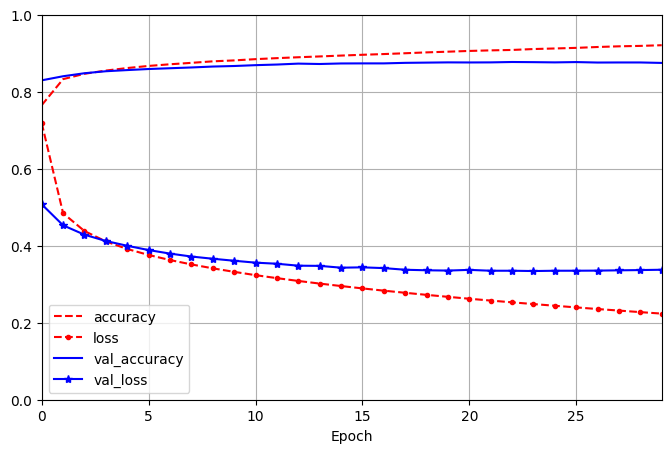

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True, xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [23]:
model.save("img_classification_sequentialAPI.h5")